# Diabetes Veri Seti

# 0.Kütüphanelerin Yüklenmesi

In [21]:
import pandas as pd  # Veri tablolarını (DataFrame) yönetmek ve manipülasyon için.
import numpy as np   # Matematiksel işlemler ve NaN (boş veri) yönetimi için.
import matplotlib.pyplot as plt # Grafiklerin temel iskeleti ve eksen yönetimi için.
import seaborn as sns           # Şık ve istatistiksel odaklı görselleştirmeler için.
from sklearn.preprocessing import StandardScaler # Değişkenleri ortak bir ölçeğe getirmek için.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
%matplotlib inline
# Grafiklerin notebook içinde satır içi görünmesini sağlar.
sns.set(style="whitegrid") # Okunabilirliği artırmak için arka plana ızgara ekler.

## 0. Verinin Yüklenmesi

In [22]:
df = pd.read_csv('diabetes.csv') # CSV dosyasını DataFrame olarak RAM'e yükler.
df.head() # Yüklemenin doğruluğunu teyit etmek için ilk 5 satırı gösterir.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1.1 EDA - Veri Kümesi Açıklaması

Veri setimiz kadınlarının sağlık verilerinden oluşmaktadır. 

### Değişkenlerin Karakteristiği:
1. **Pregnancies:** Hamilelik sayısı.
2. **Glucose:** 2 saatlik glikoz tolerans testi sonucu. Diyabetun en güçlü öncülüdür.
3. **BloodPressure:** Diastolik kan basıncı.
4. **SkinThickness:** Cilt kalınlığı ölçümü.
5. **Insulin:** 2 saatlik serum insülini.
6. **BMI:** Vücut Kitle İndeksi (Kilo/Boy^2).
7. **DiabetesPedigreeFunction:** Genetik diyabet yatkınlık skoru.
8. **Age:** Yaş.
9. **Outcome:** Hedef değişken (1: Diyabet Pozitif, 0: Negatif).

# 1.2 EDA - İSTATIKSEL ÖZET

In [23]:
# Veri setinin satır ve sütun sayısını görmek için:
print(f"Veri Seti Boyutu: {df.shape}")

# Değişkenlerin veri tiplerini ve bellek kullanımını kontrol etmek için:
df.info()

# Diyabetik (1) ve Sağlıklı (0) hasta sayıları ve oranları:
print("Sınıf Dağılımı:")
print(df["Outcome"].value_counts())
print("\nSınıf Oranları:")
print(df["Outcome"].value_counts(normalize=True))

# Çiftleyen satır kontrolü:
print(f"\nTekrar Eden Satır Sayısı: {df.duplicated().sum()}")

Veri Seti Boyutu: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Sınıf Dağılımı:
Outcome
0    500
1    268
Name: count, dtype: int64

Sınıf Oranları:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Tekrar Eden Satır Sayısı: 0


# 1.3 EDA - VERİ GÖRSELLEŞTİRME

C:\Users\mrsci\AppData\Local\Temp\ipykernel_11700\4125470350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


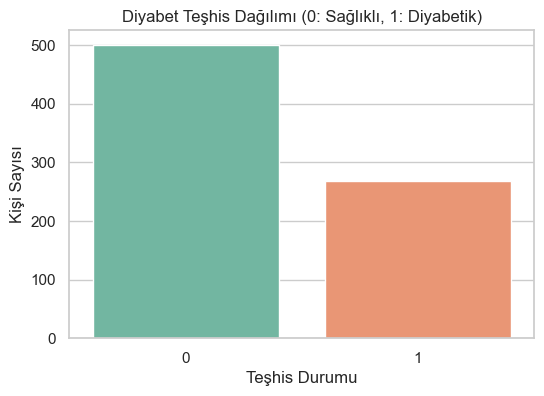

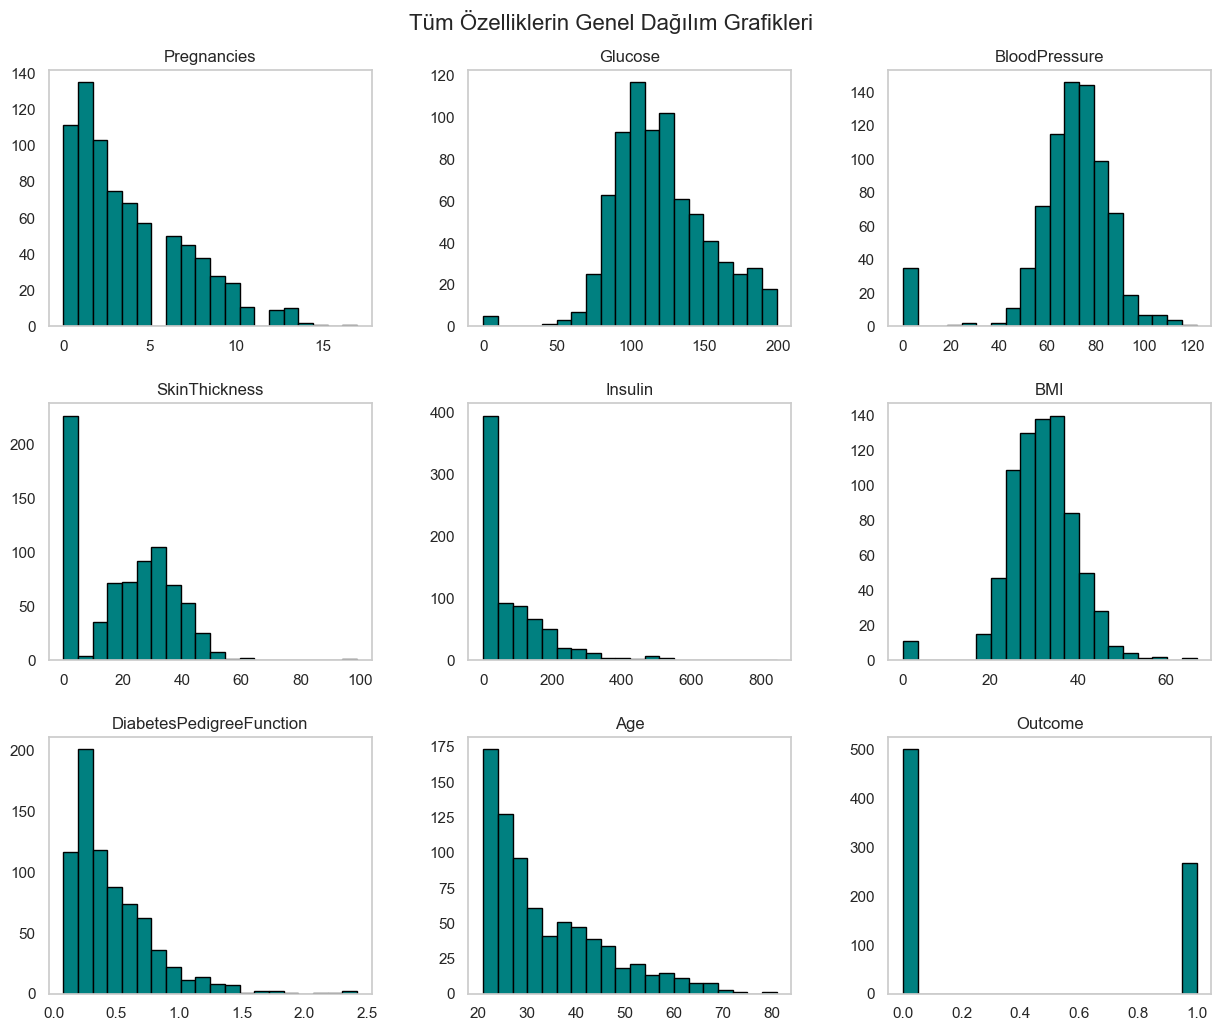

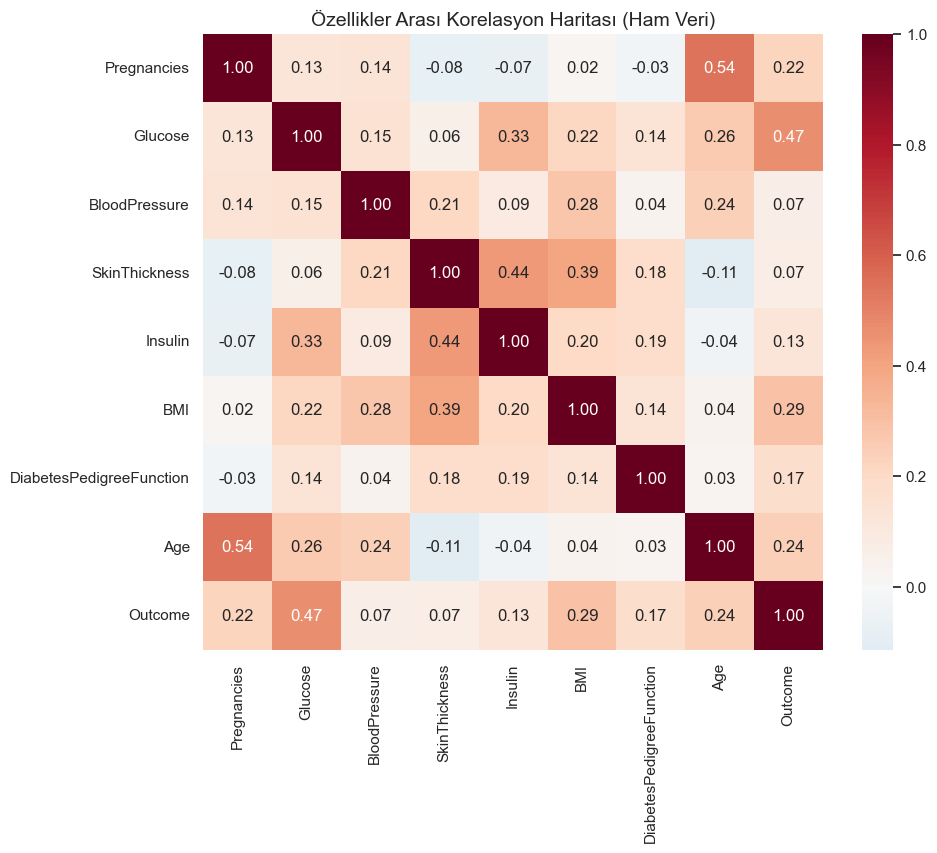

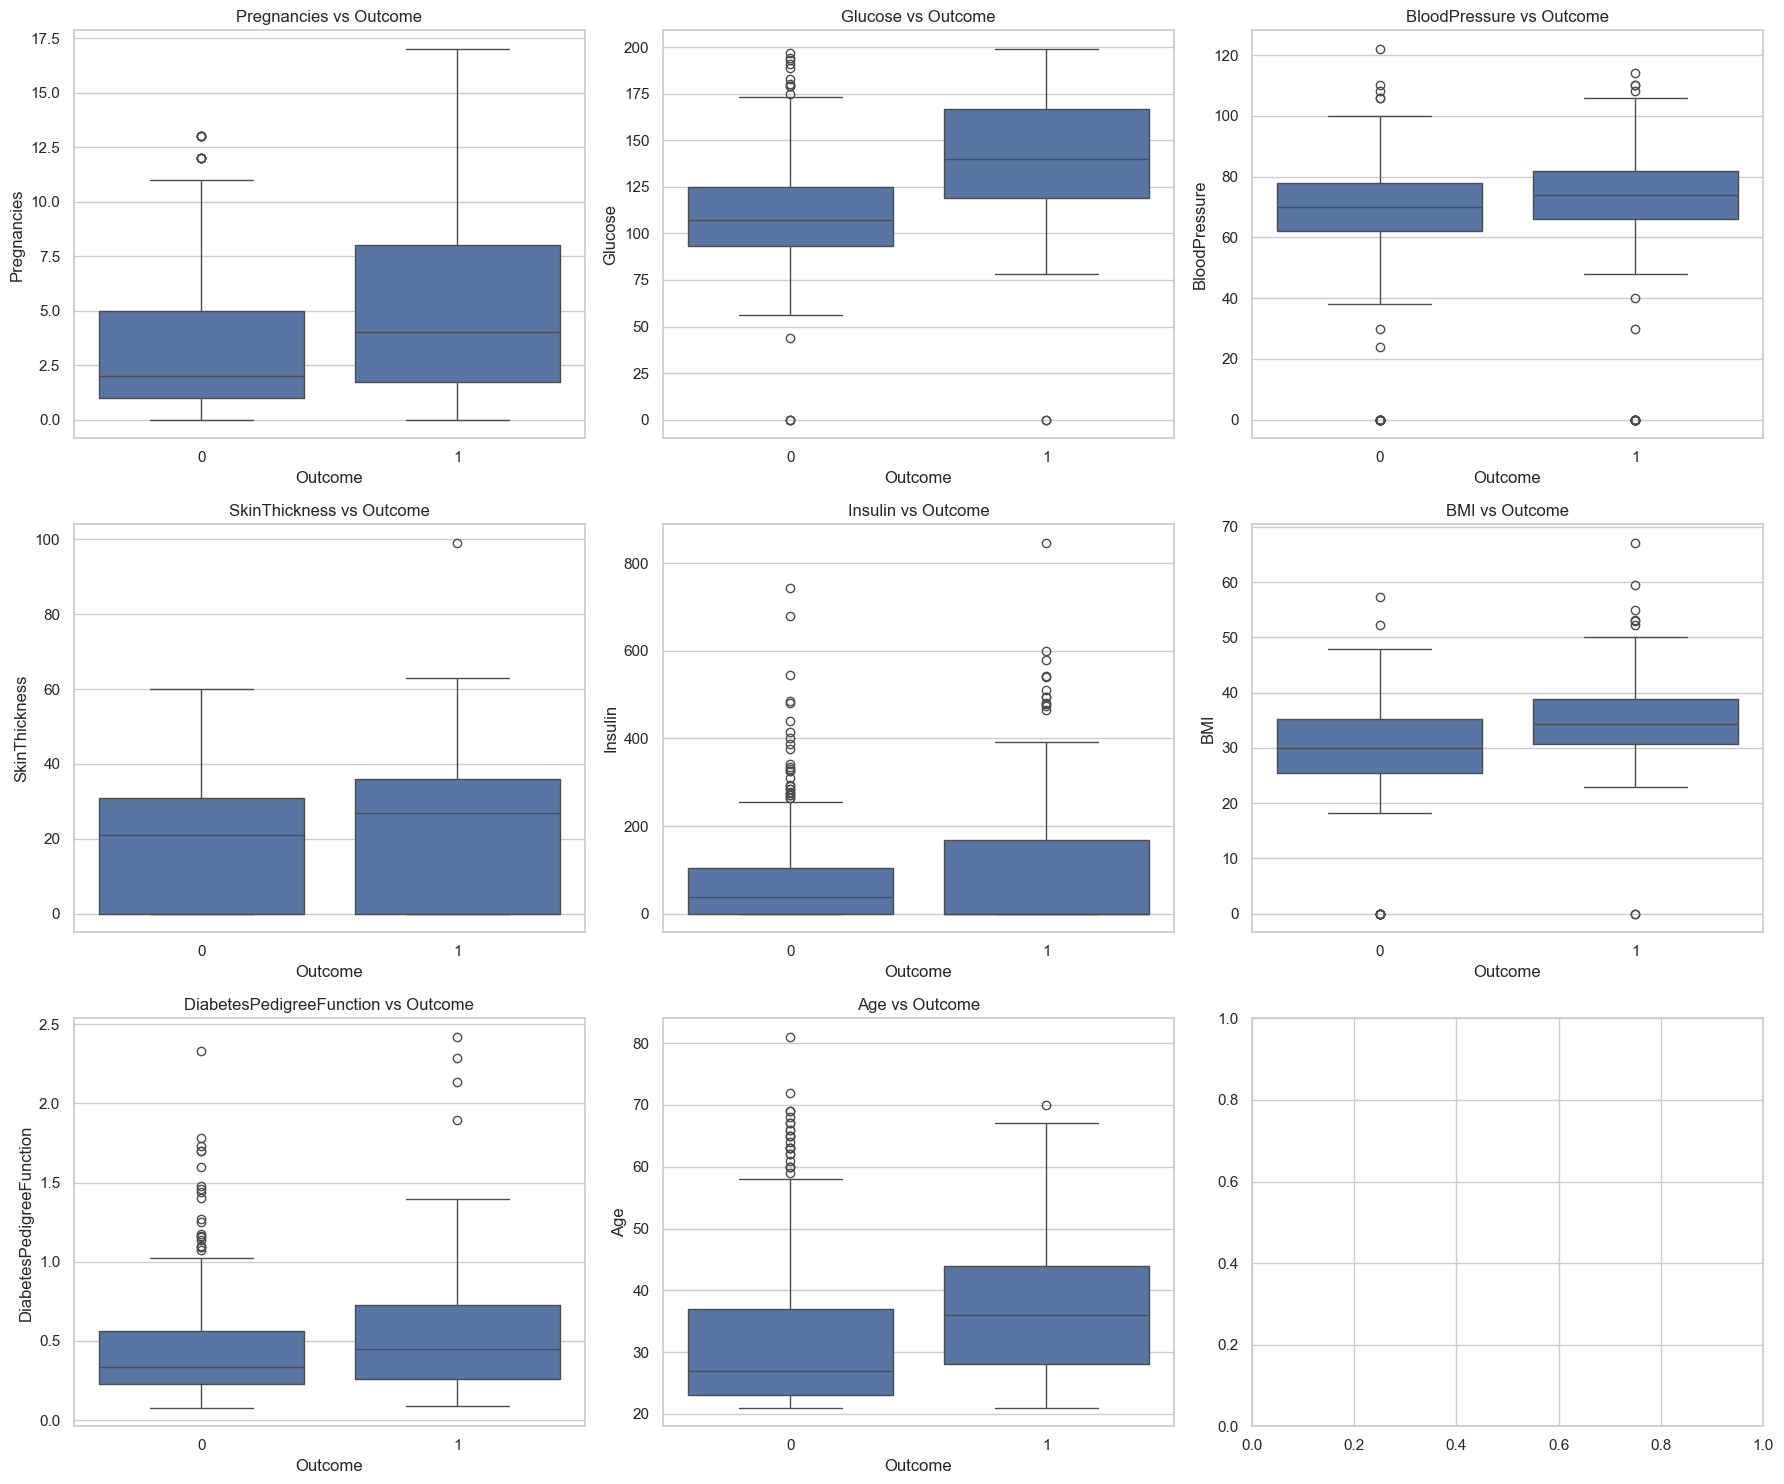

In [24]:
#### A. Hedef Değişken Dağılımı (Sütun Grafiği)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diyabet Teşhis Dağılımı (0: Sağlıklı, 1: Diyabetik)')
plt.xlabel('Teşhis Durumu')
plt.ylabel('Kişi Sayısı')
plt.show()

# Tüm sayısal değişkenlerin dağılımını toplu olarak çizdirme
df.hist(figsize=(15, 12), bins=20, color='teal', edgecolor='black', grid=False)
plt.suptitle('Tüm Özelliklerin Genel Dağılım Grafikleri', fontsize=16, y=0.93)
plt.show()

# Isı Haritası (Correlation Heatmap) ile değişkenler arası ilişkileri görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Özellikler Arası Korelasyon Haritası (Ham Veri)', fontsize=14)
plt.show()

# Hedef Bazlı Kıyaslama (Boxplot)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Outcome')
plt.tight_layout()
plt.show()

# 2.1 VERİ TEMİZLEME - EKSİK VE GEÇERSİZ VERİLERİN TESPİTİ VE TEMİZLENMESİ

In [25]:
# Biyolojik olarak 0 olamayacak sütunları tanımlıyoruz.
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Orijinal veriyi korumak için kopya alıyoruz.
df_temp = df.copy()

# 0'ları NaN yaparak tutarsızlıkları işaretliyoruz.
df_temp[invalid_zero_cols] = df_temp[invalid_zero_cols].replace(0, np.nan)

print("Geçersiz sıfır değerleri başarıyla NaN olarak işaretlendi. Doldurma işlemi Preprocessing adımında yapılacak.")

Geçersiz sıfır değerleri başarıyla NaN olarak işaretlendi. Doldurma işlemi Preprocessing adımında yapılacak.


# 2.2 VERİ TEMİZLEME - AYKIRI DEĞER TESPİTİ VE TUTARSIZLIKLARI GİDERMEK

In [26]:
# 1. IQR Sınırlarını Hesaplama Fonksiyonu
def outlier_thresholds(dataframe, col, q1=0.25, q3=0.75):
    quartile1 = dataframe[col].quantile(q1)
    quartile3 = dataframe[col].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

# 2. Aykırı Değer Var mı Kontrol Etme Fonksiyonu
def check_outliers(dataframe, col):
    low, up = outlier_thresholds(dataframe, col)
    has_outlier = ((dataframe[col] < low) | (dataframe[col] > up)).any()
    return has_outlier

# 3. Baskılama (Capping / Winsorization) Fonksiyonu
# Not: Bu fonksiyonu modelleme öncesi train/test setlerine sızıntısız uygulayacağız.
def replace_with_thresholds(dataframe, col, low_limit, up_limit):
    dataframe.loc[dataframe[col] < low_limit, col] = low_limit
    dataframe.loc[dataframe[col] > up_limit, col] = up_limit

# 4. Uygulama ve Tespit (Outcome hariç tüm sayısal sütunlar)
cols = [c for c in df_temp.columns if c != "Outcome"]

# Sadece Tespit (Detection) gerçekleştiriliyor
print("Temizlik Öncesi Aykırı Değer Durumu (Tespit):")
for col in cols:
    print(f"{col}: {check_outliers(df_temp, col)}")

print("\nVeri sızıntısını önlemek için baskılama (Treatment) limitleri Train setinden hesaplanıp uygulanacaktır.")

Temizlik Öncesi Aykırı Değer Durumu (Tespit):
Pregnancies: True
Glucose: False
BloodPressure: True
SkinThickness: True
Insulin: True
BMI: True
DiabetesPedigreeFunction: True
Age: True

Veri sızıntısını önlemek için baskılama (Treatment) limitleri Train setinden hesaplanıp uygulanacaktır.


# 3.1 VERİ ÖNİZLEME - KATEGORİK DEĞİŞKENLERİN KODLANMASI ve TRAIN-TEST SPLIT

In [27]:
# Orijinal veri setinde bağımsız kategorik değişken bulunmadığından, 
# "Encoding categorical variables (if applicable)" adımı ham veri için geçersizdir.
# İlerleyen adımlarda türetilecek kategorik özellikler kendi aşamasında encode edilecektir.

# Veri sızıntısını (Data Leakage) kesin olarak önlemek adına öncelikle veriyi bölüyoruz.
X = df_temp.drop('Outcome', axis=1)
y = df_temp['Outcome']

# Sınıf dağılım oranını korumak için stratify=y parametresini ekliyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim Seti Boyutu (X_train): {X_train.shape}")
print(f"Test Seti Boyutu (X_test): {X_test.shape}")

Eğitim Seti Boyutu (X_train): (614, 8)
Test Seti Boyutu (X_test): (154, 8)


# 3.2 VERİ ÖNİŞLEME - ÖLÇEKLENDİRME / NORMALİZASYON / ÇARPIKLIK ANALİZİ

C:\Users\mrsci\AppData\Local\Temp\ipykernel_11700\2371422311.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[col] < low_limit, col] = low_limit
C:\Users\mrsci\AppData\Local\Temp\ipykernel_11700\2371422311.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-6.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[dataframe[col] < low_limit, col] = low_limit
C:\Users\mrsci\AppData\Local\Temp\ipykernel_11700\2371422311.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  datafr

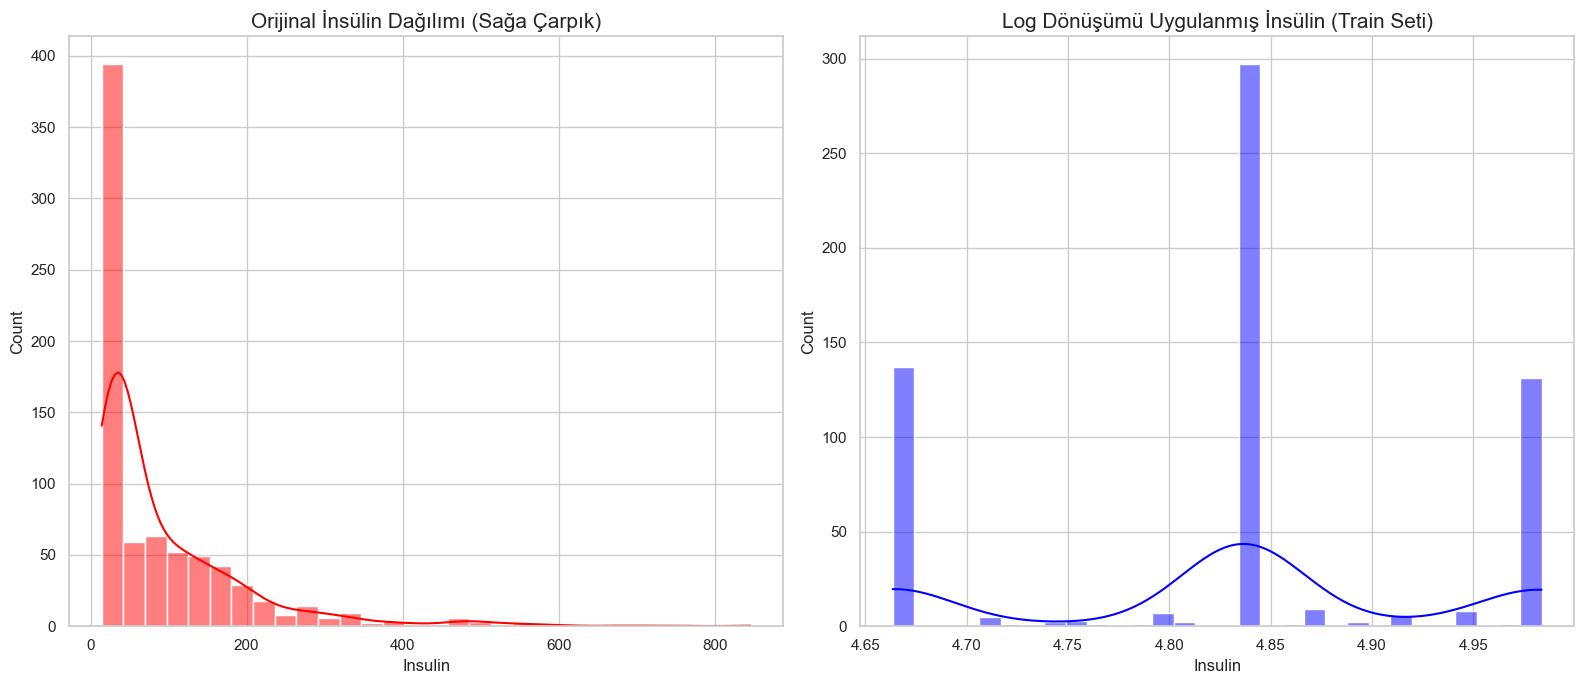

Eksik veriler dolduruldu, aykırı değerler baskılandı, log dönüşümü yapıldı ve sızıntısız ölçeklendi


In [28]:
# --- KISIM 1: ERTELENEN EKSİK VERİ DOLDURMA (SİZINTISIZ) ---
# Medyanları sadece X_train üzerinden öğrenip, iki seti de sızıntısız dolduruyoruz
for col in invalid_zero_cols:
    train_median = X_train[col].median()
    X_train[col] = X_train[col].fillna(train_median)
    X_test[col] = X_test[col].fillna(train_median)


# --- KISIM 2: ERTELENEN AYKIRI DEĞER BASKILAMA (SİZINTISIZ) ---
# Limitleri sadece X_train üzerinden hesaplayıp, iki sete de sızıntısız uyguluyoruz
cols_to_cap = [c for c in X_train.columns]
for col in cols_to_cap:
    low_lim, up_lim = outlier_thresholds(X_train, col) # 2.2'deki fonksiyonumuz
    replace_with_thresholds(X_train, col, low_lim, up_lim) # 2.2'deki fonksiyonumuz
    replace_with_thresholds(X_test, col, low_lim, up_lim)


# --- KISIM 3: ÇARPIKLIK ANALİZİ & LOG DÖNÜŞÜMÜ ---
plt.figure(figsize=(16, 7))

# Sol tarafa orijinal (0'ları temizlenmiş ham veri) dağılımını çiziyoruz
plt.subplot(1, 2, 1) 
sns.histplot(df['Insulin'].replace(0, np.nan).fillna(df['Insulin'].median()), kde=True, color='red', bins=30)
plt.title('Orijinal İnsülin Dağılımı (Sağa Çarpık)', fontsize=15)

# Sağ tarafa logaritmik dönüşümü kalıcı olarak uygulayıp çiziyoruz
X_train['Insulin'] = np.log1p(X_train['Insulin'])
X_test['Insulin'] = np.log1p(X_test['Insulin'])

plt.subplot(1, 2, 2) 
sns.histplot(X_train['Insulin'], kde=True, color='blue', bins=30)
plt.title('Log Dönüşümü Uygulanmış İnsülin (Train Seti)', fontsize=15)

plt.tight_layout()
plt.show()


# --- KISIM 4: ÖLÇEKLENDİRME / NORMALİZASYON ---
# Scaler sadece X_train ile eğitilir (fit), X_test sadece dönüştürülür (transform)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Eksik veriler dolduruldu, aykırı değerler baskılandı, log dönüşümü yapıldı ve sızıntısız ölçeklendi")

# 4. FEATURE ENGINEERING - ANLAMLI ÖZELLİK OLUŞTURULMASI VE DEĞİŞKENLERİN DÖNÜŞTÜRÜLMESİ

In [29]:
# Orijinal verileri korumak ve train/test setlerini senkronize büyütmek için kopyalar alıyoruz
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# 1. BMI Kategorizasyonu (Hem Train hem Test için ayrı ayrı)
# Tıbbi risk gruplarına göre sayısal değerleri anlamlı kategorilere bölüyoruz
for df_set in [X_train_fe, X_test_fe]:
    df_set.loc[df_set['BMI'] < 18.5, 'BMI_CAT'] = 'Underweight'
    df_set.loc[(df_set['BMI'] >= 18.5) & (df_set['BMI'] < 25), 'BMI_CAT'] = 'Normal'
    df_set.loc[(df_set['BMI'] >= 25) & (df_set['BMI'] < 30), 'BMI_CAT'] = 'Overweight'
    df_set.loc[df_set['BMI'] >= 30, 'BMI_CAT'] = 'Obese'

# 2. Glikoz Kategorizasyonu 
# Kritik medikal eşik değerlerine göre sınıflama yapıyoruz
for df_set in [X_train_fe, X_test_fe]:
    df_set.loc[df_set['Glucose'] <= 140, 'GLUCOSE_CAT'] = 'Normal'
    df_set.loc[(df_set['Glucose'] > 140) & (df_set['Glucose'] <= 199), 'GLUCOSE_CAT'] = 'Prediabetic'
    df_set.loc[df_set['Glucose'] > 199, 'GLUCOSE_CAT'] = 'Diabetic'

# 3. Etkileşim Değişkeni (Interaction)
# Glikoz ve İnsülin çarpımı ile metabolik efor göstergesi türetiyoruz
X_train_fe['Glucose_Insulin_Ratio'] = X_train_fe['Glucose'] * X_train_fe['Insulin']
X_test_fe['Glucose_Insulin_Ratio'] = X_test_fe['Glucose'] * X_test_fe['Insulin']


# 4. ÖNCEKİ ADIMDA SİLİNEN KATEGORİK DÖNÜŞÜM (ONE-HOT ENCODING) 
# Türettiğimiz metinsel risk gruplarını modellere beslemek için 1 ve 0'lara çeviriyoruz
# drop_first=True: Kukla değişken tuzağını (multicollinearity) önler.
# dtype=int: Pandas 2.0+ sürümlerinde True/False yerine 1/0 basmasını zorunlu kılar.
X_train_encoded = pd.get_dummies(X_train_fe, columns=['BMI_CAT', 'GLUCOSE_CAT'], drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test_fe, columns=['BMI_CAT', 'GLUCOSE_CAT'], drop_first=True, dtype=int)


# 5. YENİ SAYISAL ÖZELLİĞİN SIZINTISIZ ÖLÇEKLENMESİ 
# Yeni türettiğimiz 'Glucose_Insulin_Ratio' sayısal bir değişken olduğu için onu da ölçeklemeliyiz.
# Eski ölçeklenmiş özellikleri 3.2 adımında X_train_scaled ve X_test_scaled olarak kaydetmiştik.
ratio_scaler = StandardScaler()

X_train_ratio_scaled = ratio_scaler.fit_transform(X_train_encoded[['Glucose_Insulin_Ratio']])
X_test_ratio_scaled = ratio_scaler.transform(X_test_encoded[['Glucose_Insulin_Ratio']])

# 3.2'de ölçeklediğimiz ana özelliklerle, yeni türettiğimiz encode edilmiş özellikleri birleştiriyoruz
dummy_cols = [col for col in X_train_encoded.columns if 'BMI_CAT_' in col or 'GLUCOSE_CAT_' in col]

X_train_final = X_train_scaled.copy()
X_test_final = X_test_scaled.copy()

# Yeni özellikleri nihai matrise ekleme
X_train_final['Glucose_Insulin_Ratio'] = X_train_ratio_scaled
X_test_final['Glucose_Insulin_Ratio'] = X_test_ratio_scaled

X_train_final = pd.concat([X_train_final, X_train_encoded[dummy_cols]], axis=1)
X_test_final = pd.concat([X_test_final, X_test_encoded[dummy_cols]], axis=1)

print("Yeni özellikler türetildi, ertelenen One-Hot Encoding yapıldı ve nihai matrisler sızıntısız birleştirildi")
print(f"Modelleme Öncesi Final Train Seti Şekli: {X_train_final.shape}")

Yeni özellikler türetildi, ertelenen One-Hot Encoding yapıldı ve nihai matrisler sızıntısız birleştirildi
Modelleme Öncesi Final Train Seti Şekli: (614, 13)


# 5. Modelleme

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- MODEL SEÇİM  ---
# 1. Logistic Regression: Doğrusal ilişkileri görmek için temel çizgi (Baseline) modeli.
# 2. Random Forest: Verideki non-lineer ilişkileri ve varyansı ehlileştirmek için güçlü bir topluluk modeli.
# 3. Gradient Boosting: Hata odaklı ağaç yapısıyla en yüksek tahmini performansı zorlamak için seçilmiştir.
# 4. SVM: Özellikle yüksek boyutlu ve karmaşık veri setlerinde etkili olan bir sınıflandırıcı.
# 5. KNN: Komşuluk temelli basit ama etkili bir algoritma, özellikle küçük veri setlerinde işe yarar.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

# Modellerin Eğitim Seti Üzerinden Eğitilmesi
# NOT: 4. adımdan gelen sızıntısız, nihai X_train_final matrisini besliyoruz.
for name, model in models.items():
    model.fit(X_train_final, y_train)

print("Tüm makine öğrenmesi modelleri veri sızıntısı olmadan başarıyla eğitildi!")

Tüm makine öğrenmesi modelleri veri sızıntısı olmadan başarıyla eğitildi!


# 6. Model Evaluation & Comparison 

In [31]:
# Sonuçları saklamak için boş liste
results = []

# 5. adımdaki hücrede zaten eğitilmiş olan modelleri doğrudan döngüye alıyoruz (fit işlemi kaldırıldı)
# NOT: Tahmin üretirken 4. adımdan gelen sızıntısız ve tam hazır X_test_final matrisini besliyoruz.
for name, model in models.items():
    y_pred = model.predict(X_test_final)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Karşılaştırma Tablosunun Oluşturulması
# Tabloyu Accuracy yerine dengeli metrik olan F1-Score'a göre büyükten küçüğe sıralıyoruz.
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
df_results

,Model,Accuracy,Precision,Recall,F1-Score
4,KNN,0.759740,0.707317,0.537037,0.610526
2,Gradient Boosting,0.746753,0.666667,0.555556,0.606061
1,Random Forest,0.727273,0.636364,0.518519,0.571429
0,Logistic Regression,0.694805,0.574468,0.500000,0.534653
3,SVM,0.707792,0.609756,0.462963,0.526316
